# WVS Wave 7 — Exploratory Analysis and Preprocessing
This notebook prepares and explores the World Values Survey Wave 7 dataset for cross-cultural analysis.
It demonstrates the following steps:
- loading and validating the raw dataset
- mapping countries to cultural regions
- filtering and cleaning questionnaire responses
- analysing missing data by region
- visualising normalised regional mean responses with a heatmap

## 1. Setup & Data Loading

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Consistent plotting style
sns.set_theme(style="white")

# Load the World Values Survey Wave 7 dataset
file_path = "WVS_Cross-National_Wave_7_csv_v6_0.csv"
df = pd.read_csv(file_path)

# Basic dataset validation
print(f"Raw dataset shape: {df.shape}")
print(f"Country count: {df['B_COUNTRY_ALPHA'].nunique()}")
print(f"Columns loaded: {len(df.columns)}")

# Display a preview of the dataset
df.head()


C:\Users\daanj\AppData\Local\Temp\ipykernel_22436\1577168789.py:13: DtypeWarning: Columns (346,348,350,580,581,582,583) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Raw dataset shape: (97220, 613)
Country count: 66
Columns loaded: 613


,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
0,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070001,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070002,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070003,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070005,...,66.964286,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


## 2. Region Mapping

Countries are mapped to cultural regions using a simplified Inglehart–Welzel classification.
Responses from countries without a mapping are excluded from further analysis to keep the regional comparisons consistent.

In [3]:
# Country-to-region mapping based on a simplified
# Inglehart–Welzel cultural classification.
region_mapping = {
    # Orthodox Europe
    'ARM': 'Orthodox Europe', 'RUS': 'Orthodox Europe', 'UKR': 'Orthodox Europe',
    'ROU': 'Orthodox Europe', 'GRC': 'Orthodox Europe', 'SRB': 'Orthodox Europe',

    # African-Islamic
    'TUN': 'African-Islamic', 'EGY': 'African-Islamic', 'MAR': 'African-Islamic',
    'LBY': 'African-Islamic', 'KEN': 'African-Islamic', 'ETH': 'African-Islamic',
    'ZWE': 'African-Islamic', 'NGA': 'African-Islamic', 'KAZ': 'African-Islamic',
    'UZB': 'African-Islamic', 'TJK': 'African-Islamic', 'KGZ': 'African-Islamic',
    'IDN': 'African-Islamic', 'PAK': 'African-Islamic', 'IRN': 'African-Islamic',
    'BGD': 'African-Islamic', 'TUR': 'African-Islamic', 'JOR': 'African-Islamic',
    'IRQ': 'African-Islamic', 'LBN': 'African-Islamic',

    # Latin America
    'PRI': 'Latin America', 'MEX': 'Latin America', 'GTM': 'Latin America',
    'NIC': 'Latin America', 'BOL': 'Latin America', 'BRA': 'Latin America',
    'COL': 'Latin America', 'PER': 'Latin America', 'ECU': 'Latin America',
    'VEN': 'Latin America', 'ARG': 'Latin America', 'CHL': 'Latin America',
    'URY': 'Latin America',

    # West & South Asia
    'SGP': 'West & South Asia', 'THA': 'West & South Asia',
    'MYS': 'West & South Asia', 'VNM': 'West & South Asia',
    'MMR': 'West & South Asia', 'PHL': 'West & South Asia',
    'IND': 'West & South Asia',

    # Confucian
    'CHN': 'Confucian', 'HKG': 'Confucian', 'MNG': 'Confucian',
    'JPN': 'Confucian', 'KOR': 'Confucian', 'TWN': 'Confucian',
    'MAC': 'Confucian',

    # Catholic Europe
    'SVK': 'Catholic Europe', 'CZE': 'Catholic Europe',
    'AND': 'Catholic Europe',

    # English-speaking
    'CAN': 'English-speaking', 'USA': 'English-speaking',
    'GBR': 'English-speaking', 'NIR': 'English-speaking',
    'AUS': 'English-speaking', 'NZL': 'English-speaking',

    # Protestant Europe
    'NLD': 'Protestant Europe',
    'DEU': 'Protestant Europe',
}

# Assign cultural region labels to each respondent.
df['Region_Group'] = df['B_COUNTRY_ALPHA'].map(region_mapping)

# Review region coverage before filtering.
print("Rows per region (NaN = unmapped countries):")
print(df['Region_Group'].value_counts(dropna=False))

# Identify countries not included in the mapping.
print("\nUnmapped country codes:")
print(sorted(df.loc[df['Region_Group'].isna(), 'B_COUNTRY_ALPHA'].unique()))


Rows per region (NaN = unmapped countries):
Region_Group
African-Islamic      28590
Latin America        17439
English-speaking     12540
Confucian            11593
West & South Asia    10117
Orthodox Europe       7825
Protestant Europe     3673
Catholic Europe       3404
NaN                   2039
Name: count, dtype: int64

Unmapped country codes:
['CYP', 'MDV']


## 3. Filtering & Cleaning

The dataset is filtered to include only respondents with a valid cultural region assignment.
Relevant questionnaire items are retained, and non-response codes are converted to missing values.
An invalid response category in `Q111` is also recoded as missing.

In [ ]:
QUESTION_COLS = [
    'Q106', 'Q107', 'Q108', 'Q109', 'Q110', 'Q111',
    'Q164', 'Q165', 'Q166', 'Q167', 'Q168', 'Q169', 'Q170', 'Q171',
    'Q172', 'Q173', 'Q174', 'Q175', 'Q176', 'Q177', 'Q178', 'Q179',
    'Q180', 'Q181', 'Q182', 'Q183', 'Q184', 'Q185', 'Q186', 'Q187',
    'Q188', 'Q189', 'Q190', 'Q191', 'Q192', 'Q193', 'Q194', 'Q195',
    'Q196', 'Q197', 'Q198'
]

KEEP_COLS = ['B_COUNTRY', 'B_COUNTRY_ALPHA', 'Region_Group'] + QUESTION_COLS

# Drop unmapped countries and restrict to relevant columns
df_filtered = df.dropna(subset=['Region_Group'])[KEEP_COLS].copy()

# Replace negative values (non-responses) with NaN
df_filtered[QUESTION_COLS] = df_filtered[QUESTION_COLS].where(df_filtered[QUESTION_COLS] >= 0, np.nan)

# Q111=3 is an invalid category - recode to NaN
df_filtered['Q111'] = df_filtered['Q111'].replace(3, np.nan)

print(f"Original shape : {df.shape}")
print(f"Filtered shape : {df_filtered.shape}")

Original shape : (97220, 614)
Filtered shape : (95181, 44)


## 4. Missing Value Analysis

For each question, the proportion of missing values is calculated per region. High missingness in a region may indicate that a question was not asked there, or reflects cultural non-response patterns.

In [5]:
records = []

for col in QUESTION_COLS:
    grouped = df_filtered.groupby('Region_Group')[col]
    non_missing = grouped.count().rename('non_missing')
    missing     = grouped.apply(lambda x: x.isnull().sum()).rename('missing')

    tmp = pd.DataFrame({'non_missing': non_missing, 'missing': missing}).reset_index()
    tmp['total']               = tmp['missing'] + tmp['non_missing']
    tmp['missing_proportion']  = tmp['missing'] / tmp['total']
    tmp['Question']            = col
    records.append(tmp[['Region_Group', 'Question', 'missing_proportion']])

missing_proportions_df = (
    pd.concat(records, ignore_index=True)
    .sort_values('missing_proportion', ascending=False)
    .reset_index(drop=True)
)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(missing_proportions_df)

,Region_Group,Question,missing_proportion
0,English-speaking,Q175,0.258852
1,English-speaking,Q174,0.254705
2,English-speaking,Q189,0.250000
3,African-Islamic,Q183,0.235922
4,Protestant Europe,Q166,0.196025
5,African-Islamic,Q193,0.193844
6,Protestant Europe,Q170,0.183229
7,Protestant Europe,Q175,0.172883
8,Orthodox Europe,Q166,0.169201
9,Orthodox Europe,Q167,0.168818


## 5. Heatmap - Normalised Mean Responses by Region

Each question is Min-Max scaled to [0, 1] across all respondents, then a country-weighted regional mean is computed (country mean first, then region mean) to avoid bias from countries with larger sample sizes.

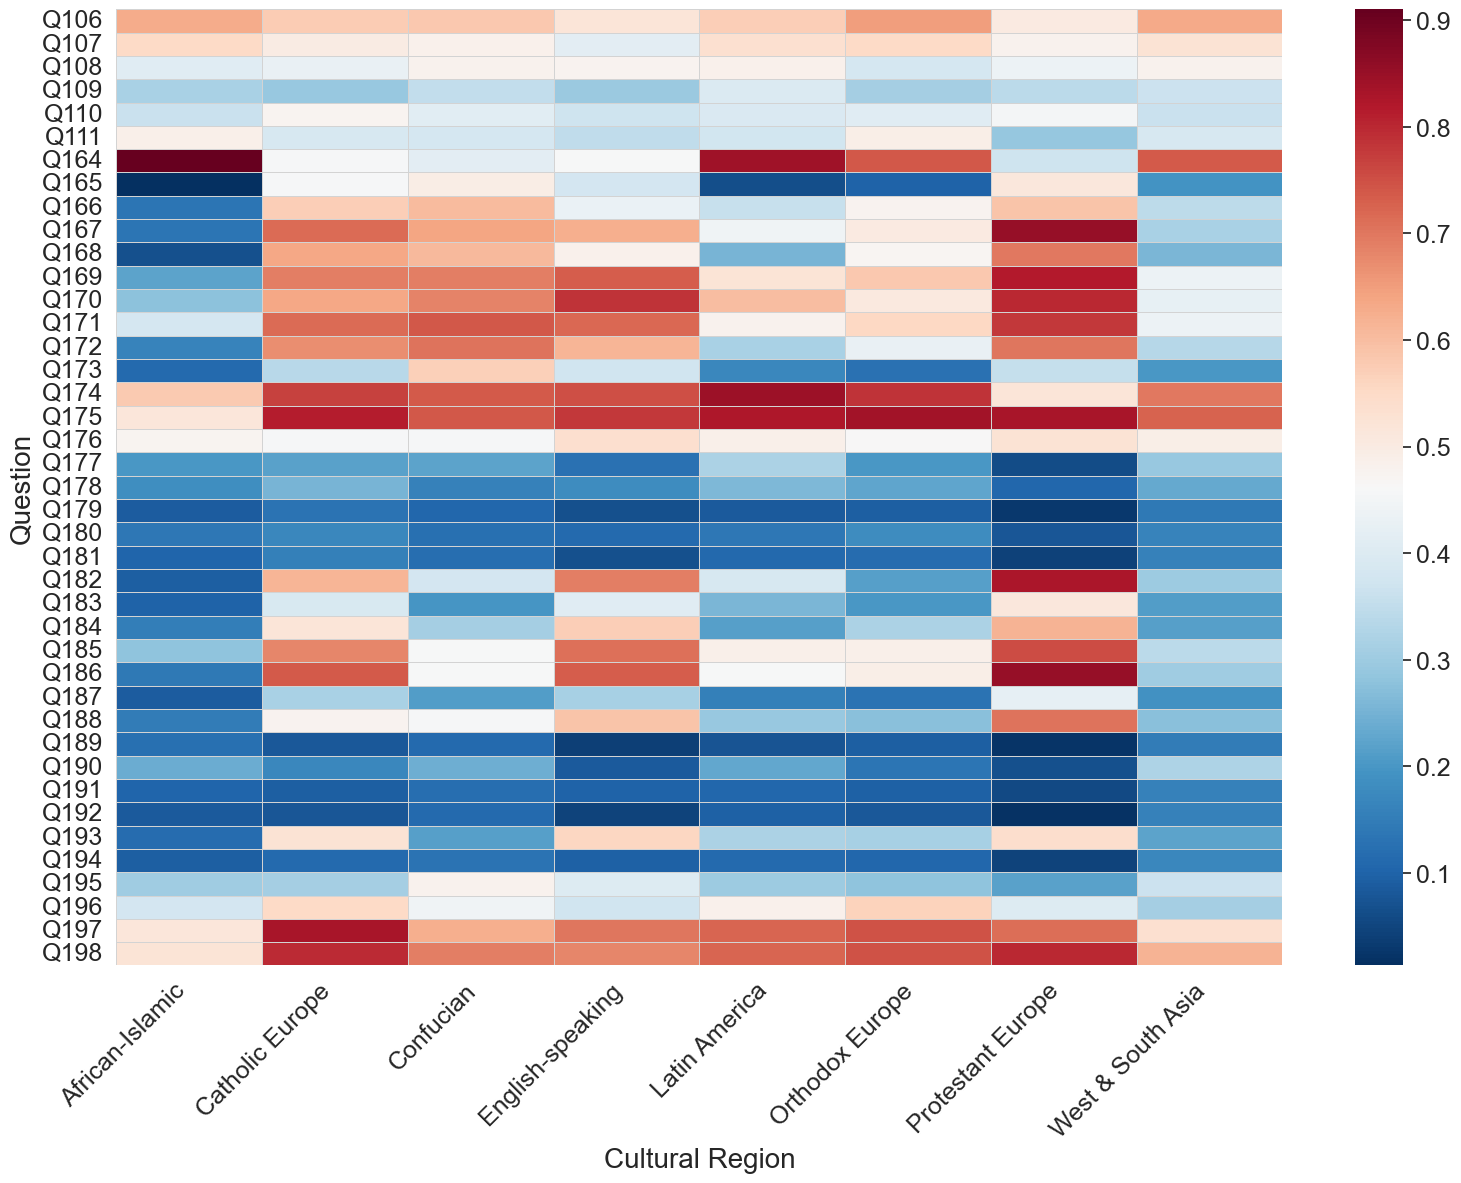

In [6]:
scaler = MinMaxScaler()
df_scaled = df_filtered[['B_COUNTRY_ALPHA', 'Region_Group'] + QUESTION_COLS].copy()

# Min-Max scale each question across all (non-NaN) responses
for q in QUESTION_COLS:
    mask = df_scaled[q].notna()
    if mask.any():
        df_scaled.loc[mask, q] = scaler.fit_transform(
            df_scaled.loc[mask, q].values.reshape(-1, 1)
        ).flatten()

# Country-weighted regional mean: average per country first, then per region
country_means = df_scaled.groupby(['Region_Group', 'B_COUNTRY_ALPHA'])[QUESTION_COLS].mean()
region_means  = country_means.groupby('Region_Group')[QUESTION_COLS].mean()

# Plot
plt.figure(figsize=(16, 12))

ax = sns.heatmap(
    region_means.T,
    cmap=sns.color_palette("RdBu_r", as_cmap=True),
    annot=False,
    linewidths=0.5,
    linecolor='lightgray'
)

# Axis labels
plt.xlabel('Cultural Region', fontsize=20)
plt.ylabel('Question', fontsize=20)

# Axis tick labels
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(rotation=0, fontsize=18)

# Colorbar tick size (NEW)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()